# Start Here: The Governed Financial LLM Lab

**Book:** *Large Language Models in Finance*  
**Author:** Miquel Noguer i Alonso  
**Runtime:** about 1 minute · **Difficulty:** introductory · **Credentials:** none

This is the front door to the companion notebook suite. It checks the environment,
introduces the fictional point-in-time data, and executes the book's central contract:

> time-valid evidence → model proposal → deterministic control → human review

All default examples are CPU-friendly, deterministic, and safe to publish. They never
contact a live broker, use private data, or require an LLM API.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/00_start_here.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/00_start_here.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

By the end of this lab, you will be able to:

1. navigate the 17-notebook learning path;
2. distinguish publication time from decision-time availability;
3. link a material claim to identifiable evidence;
4. pass a typed tool request through a fail-closed policy gate; and
5. produce a reproducibility fingerprint for a run.


In [2]:
from pathlib import Path
import json
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import Claim, Document, EvidenceBundle, ToolCall, canonical_hash, seed_everything
from finllm_lab.governance import GuardedExecutor, PolicyGate, ToolSchema
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.rag import BM25Index, faithfulness_score
from finllm_lab.temporal import assert_documents_available

set_finance_theme()
rng = seed_everything(32413)
pd.set_option("display.max_colwidth", 70)
print("Repository: PacktPublishing/LLMs-in-Finance")
print("Python compatibility: 3.11+ | Default execution: portable CPU")


Repository: PacktPublishing/LLMs-in-Finance
Python compatibility: 3.11+ | Default execution: portable CPU


## 1. The learning path

The sequence follows the book chapter by chapter. Notebooks 04–06 form the core
governed-RAG-and-agents path; notebooks 11–15 form the assurance path. The capstone
combines both.


In [3]:
path = pd.DataFrame(
    [
        ("00", "Start here", "foundation", 10),
        ("01", "Earnings-call assistant", "foundation", 25),
        ("02", "Transformer mechanics", "foundation", 30),
        ("03", "Fine-tuning & calibration", "models", 35),
        ("04", "Point-in-time RAG", "systems", 40),
        ("05", "Governed multi-agent research", "systems", 40),
        ("06", "Hardened tool invocation", "systems", 35),
        ("07", "Front / middle / back office", "applications", 35),
        ("08", "Documents & suitability", "applications", 30),
        ("09", "Preference optimization", "models", 35),
        ("10", "Inference & capacity", "infrastructure", 30),
        ("11", "Governance control tower", "assurance", 35),
        ("12", "Evidence matrix", "assurance", 30),
        ("13", "Point-in-time forecasting", "assurance", 40),
        ("14", "Bounded autonomous agents", "frontier", 40),
        ("15", "Technical foundations", "assurance", 30),
        ("16", "Capstone", "capstone", 55),
    ],
    columns=["notebook", "lab", "track", "estimated_minutes"],
)
path


,notebook,lab,track,estimated_minutes
0,00,Start here,foundation,10
1,01,Earnings-call assistant,foundation,25
2,02,Transformer mechanics,foundation,30
3,03,Fine-tuning & calibration,models,35
4,04,Point-in-time RAG,systems,40
5,05,Governed multi-agent research,systems,40
6,06,Hardened tool invocation,systems,35
7,07,Front / middle / back office,applications,35
8,08,Documents & suitability,applications,30
9,09,Preference optimization,models,35


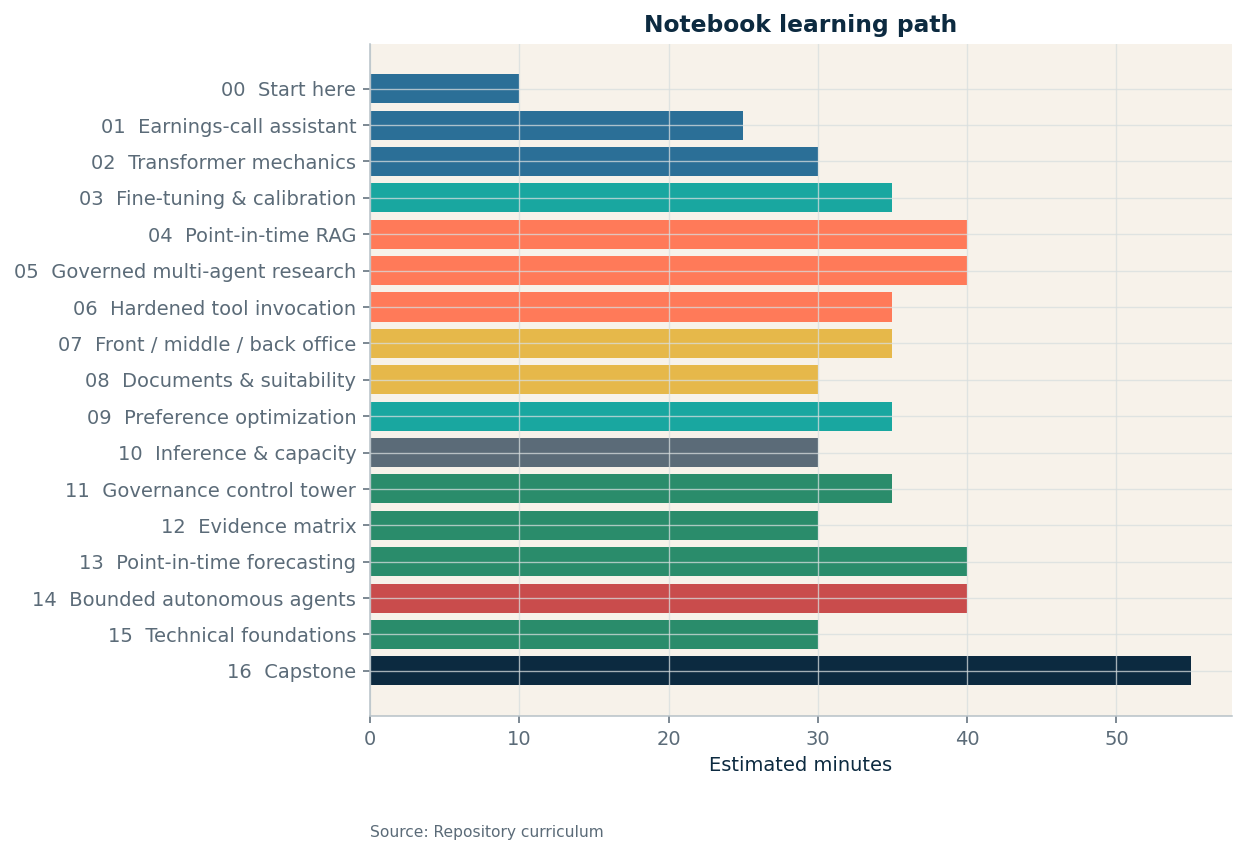

In [4]:
track_colors = {
    "foundation": COLORS["blue"],
    "models": COLORS["teal"],
    "systems": COLORS["coral"],
    "applications": COLORS["gold"],
    "infrastructure": COLORS["slate"],
    "assurance": COLORS["green"],
    "frontier": COLORS["red"],
    "capstone": COLORS["navy"],
}
fig, ax = plt.subplots(figsize=(9, 6.2))
ordered = path.iloc[::-1]
ax.barh(
    ordered["notebook"] + "  " + ordered["lab"],
    ordered["estimated_minutes"],
    color=[track_colors[t] for t in ordered["track"]],
)
ax.set_title("Notebook learning path")
ax.set_xlabel("Estimated minutes")
finish(ax, "Repository curriculum")
plt.tight_layout()


## 2. Inspect the data contract

Financial evidence is not admissible merely because it exists. The relevant timestamp
is when it became available to the system. The next cell confirms that every call has
an explicit UTC availability time and shows the latest fictional observations.


In [5]:
calls = pd.read_csv(ROOT / "data" / "earnings_calls.csv", parse_dates=["published_at", "available_at"])
data_check = pd.DataFrame(
    {
        "rows": [len(calls)],
        "issuers": [calls["ticker"].nunique()],
        "first_available": [calls["available_at"].min()],
        "last_available": [calls["available_at"].max()],
        "missing_availability": [int(calls["available_at"].isna().sum())],
        "fictional_rows": [int(calls["data_status"].eq("fictional").sum())],
    }
)
display(data_check)
calls.sort_values("available_at").tail(4)[
    ["ticker", "period", "available_at", "revenue_growth_pct", "sentiment_label"]
]


,rows,issuers,first_available,last_available,missing_availability,fictional_rows
0,84,4,2021-05-04 13:12:00+00:00,2026-05-07 13:12:00+00:00,0,84


,ticker,period,available_at,revenue_growth_pct,sentiment_label
80,ACME,2026Q1,2026-05-04 13:12:00+00:00,11.813,positive
81,NIMB,2026Q1,2026-05-05 13:12:00+00:00,13.270,positive
82,ORBT,2026Q1,2026-05-06 13:12:00+00:00,12.050,positive
83,VELA,2026Q1,2026-05-07 13:12:00+00:00,8.274,positive


## 3. Execute the minimum evidence contract

A retriever returns identifiers and passages. A claim is scored against that evidence.
The example deliberately uses a fixed decision time so the output is reproducible.


In [6]:
decision_time = datetime(2026, 3, 1, 12, tzinfo=timezone.utc)
corpus = (
    Document(
        document_id="filing-ACME-2025Q4-results",
        text="Acme Cloud Systems reported revenue growth of 11.2% for 2025Q4.",
        source="fictional 10-K",
        available_at=datetime(2026, 2, 10, 14, tzinfo=timezone.utc),
        issuer="ACME",
        section="results",
    ),
    Document(
        document_id="filing-ACME-2025Q4-risk",
        text="Key risks included cloud price competition and data-center capacity.",
        source="fictional 10-K",
        available_at=datetime(2026, 2, 10, 14, 5, tzinfo=timezone.utc),
        issuer="ACME",
        section="risk_factors",
    ),
)
assert_documents_available(corpus, decision_time)
evidence = tuple(BM25Index(corpus).search("How fast did ACME revenue grow?", k=2, decision_time=decision_time))
claim = Claim("claim-001", "ACME revenue growth was 11.2% in 2025Q4.")
score = faithfulness_score([EvidenceBundle(claim, evidence)])
pd.DataFrame(
    {
        "claim": [claim.text],
        "evidence_ids": [[item.evidence_id for item in evidence]],
        "faithfulness": [score],
    }
)


,claim,evidence_ids,faithfulness
0,ACME revenue growth was 11.2% in 2025Q4.,"[ev::filing-ACME-2025Q4-results, ev::filing-ACME-2025Q4-risk]",1.0


## 4. Put a tool call behind policy

The model may propose a call; authorization remains deterministic. Repeating the same
read-only request returns the cached result, illustrating idempotent execution.


In [7]:
call_counter = {"count": 0}

def market_snapshot(symbol: str, as_of: str) -> dict:
    call_counter["count"] += 1
    return {"symbol": symbol, "as_of": as_of, "price": 101.25, "status": "fictional"}

gate = PolicyGate(
    {"research_agent": {"market_snapshot"}},
    schemas={
        "market_snapshot": ToolSchema(
            "market_snapshot",
            required_arguments=frozenset({"symbol", "as_of"}),
        )
    },
)
executor = GuardedExecutor({"market_snapshot": market_snapshot}, gate)
request = ToolCall(
    request_id="req-start-001",
    actor="research_agent",
    tool="market_snapshot",
    arguments={"symbol": "ACME", "as_of": "2026-03-01T12:00:00+00:00"},
    requested_at=decision_time,
)
first = executor.execute(request)
second = executor.execute(request)
pd.DataFrame(
    [
        {"run": "first", "decision": first[0].status, "result": first[1]},
        {"run": "repeat", "decision": second[0].status, "result": second[1]},
    ]
), call_counter


(      run  ...                                                                 result
0   first  ...  {'symbol': 'ACME', 'as_of': '2026-03-01T12:00:00+00:00', 'price': ...
1  repeat  ...  {'symbol': 'ACME', 'as_of': '2026-03-01T12:00:00+00:00', 'price': ...

[2 rows x 3 columns],
 {'count': 1})

## 5. Reproducibility fingerprint

A material output should identify the code/data configuration that produced it. This
compact fingerprint is not a replacement for a full manifest, but it makes silent changes
immediately visible.


In [8]:
run_manifest = {
    "suite_version": "1.1.0",
    "book_production_id": "B32413",
    "seed": 32413,
    "decision_time": decision_time,
    "corpus_ids": [d.document_id for d in corpus],
    "claim": claim,
    "policy_tools": sorted(gate.permissions["research_agent"]),
    "faithfulness": score,
}
fingerprint = canonical_hash(run_manifest)
print("Run fingerprint:", fingerprint)
print("Contract status:", "PASS" if score == 1.0 and first[0].status == "allow" else "FAIL")


Run fingerprint: 8d906708bd85d127c5eff65d67d5f3dc8221ccad1fe6de8f71759c407c106761
Contract status: PASS


## Takeaways

- Availability time, not file presence, defines admissible evidence.
- Material claims need evidence identifiers and numerical support.
- LLM proposals do not authorize their own tools.
- Deterministic hashes make versions and silent changes observable.

**Next:** open `01_earnings_call_assistant.ipynb`. After completing the core
sequence, notebook 17 provides the optional real-model and SEC bridge.
